In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Convolutional Neuron

A filter of a convolutional neuron without bias term in a convolutional neural network is given by
$$
F =
\begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{bmatrix}
$$

Likewise, we have an input matrix
$$
X_1 =
\begin{bmatrix}
1 & 2 & 3 & 4 \\
4 & 5 & 7 & 8 \\
9 & 10 & 11 & 12
\end{bmatrix}
$$

Answer the following questions:

## 1) Compute the result of applying $F$ to the input $X_1$.

In [3]:
F = np.array([  [-1, 0, 1],
                [-2, 0, 2],
                [-1, 0, 1]])
X_1 = np.array([[1, 2, 3, 4],
                [4, 5, 7, 8],
                [9, 10, 11, 12]])

convolve2d(X_1, F, mode="valid")

array([[-10, -10]])

## 2) Compute the result of applying $F$ to the input $X_1$ when zero-padding of 1 is used.

In [4]:
X_1_zero1 = np.pad(X_1,1)
print(X_1_zero1)
convolve2d(X_1_zero1, F, mode="valid")

[[ 0  0  0  0  0  0]
 [ 0  1  2  3  4  0]
 [ 0  4  5  7  8  0]
 [ 0  9 10 11 12  0]
 [ 0  0  0  0  0  0]]


array([[ -9,  -7,  -7,  13],
       [-22, -10, -10,  28],
       [-25,  -7,  -7,  29]])

## 3) Consider another matrix $X_2$ with shape $224 \times 224$. What is the shape for the output for $F$ applied to $X_2$ without zero padding?

The output would have a shape of $222 \times 222$, since the filter shape of $3 \times 3$ would "cut out" 2 dimensions in both axes.

## 4) What is the shape for the output for $F$ applied to $X_2$ with a stride of 2?

With a stride of 2 it would be half the size in each dimension making the output $111 \times 111$.

# Backpropagation

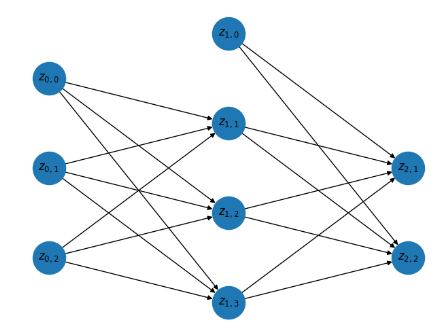

Consider the multi-layer perceptron (MLP) in Fig. 1, which aims to perform two separate binary classifications. $z_{k,i}$ is the output of the ith node of the kth layer, $z_{0,i}$ and $z_{2,i}$ are nodes of the input and output layer, respectively, and $z_{k,0} = 1$ are the nodes connected to the biases. The nodes in a given layer may be vectorized as $z_k = [z_{k,0}, z_{k,1}, \dots, z_{k,l_k}]^T$ where $l_k$ is the number of nodes in the kth layer. 

Let $w^{(k)}_{i,j}$ be the weight connecting the ith node of the (k − 1)th layer to the jth node of the kth layer, where $w^{(k)}_{0,j}$ is a bias, and let $W_k$ be the weight matrix (including biases) of size $l_{k-1} \times l_k$ connecting the outputs of the nodes of the (k − 1)th layer to the inputs of the nodes of the kth layer, where:
$$
w_k =
\begin{bmatrix}
w^{(k)}_{0,1} & \cdots & w^{(k)}_{0,l_k} \\
\vdots & \ddots & \vdots \\
w^{(k)}_{l_{k-1},1} & \cdots & w^{(k)}_{l_{k-1},l_k}
\end{bmatrix}
$$

Then $a_k = W_k^T z_{k-1}$ is a vector of the activations of the kth layer, and $z_{k-1} = h(a_{k-1})$ is a vector of the outputs of the activation function in the kth layer. The activation function for the hidden layer (k = 1) and the output layer (k = 2) is a sigmoid, i.e. $h(a) = \frac{1}{1+\exp(-a)}$. The weights of the network in Fig. 1 is given by:
$$
W_1 =
\begin{bmatrix}
0.0 & −0.9 & −0.9 \\
−0.1 & 0.7 & −0.4 \\
0.6 & −1.0 & −0.8
\end{bmatrix}
\qquad
W_2 =
\begin{bmatrix}
−0.9 & −0.1 \\
0.7 & 0.5 \\
−1.0 & 0.3 \\
0.1 & 0.0
\end{bmatrix}
$$

In the following problems, show your intermediate calculations:

## 1) Given the input vector $x = [−0.4 \quad 0.0]^T$ , show that the output of the network $y_1(x, \{w_1, w_2\}) = [0.322 \quad 0.556]^T$ .

In [5]:
W_1 = np.array([[0.0, -0.9, -0.9],
                [-0.1, 0.7, -0.4],
                [0.6, -1.0, -0.8]])
W_2 = np.array([[-0.9, -0.1],
                [0.7, 0.5],
                [-1.0, 0.3],
                [0.1, 0.0]])
weigths = [W_1, W_2]

x = np.array([[-0.4, 0.0]]).T

# slide 450
def neuron_transformation(x, W, h):
    xbias = np.vstack(([1.0], x))
    a = W.T @ xbias
    z = h(a)
    return a, z

# slide 452
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

def forward(x, weigths, h):
    activations = []
    outputs = []
    z = x
    for W in weigths:
        a, z = neuron_transformation(z, W, h)
        activations.append(a)
        outputs.append(z)
    return outputs[-1], activations, outputs

y, activations, outputs = forward(x, weigths, sigmoid)
y

array([[0.32174747],
       [0.55614102]])

## 2) Given input vector $x$ and the target vector $t = [0 \quad 0]^T$ , show that the cross-entropy error is $E(x, \{w_1, w_2\}) = 1.20$.

In [6]:
t = np.array([[0, 0]]).T

# slide 344
def cross_entropy_error(y, t):
    N = len(y)
    E = 0
    for n in range(N):
        E -= t[n] * np.log(y[n]) + (1 - t[n]) * np.log(1 - y[n])
    return E[0]

cross_entropy_error(y, t)

1.2004839696098184

## 3) Use backpropagation to show that the derivative of the error w.r.t. the weight $w^{(1)}_{1,3}$ and the bias $w^{(2)}_{0,2}$ equals $\frac{\partial E}{\partial w^{(1)}_{1,1}} = -0.05$ and $\frac{\partial E}{\partial w^{(2)}_{0,2}} = 0.556$, respectively.

In [7]:
# slide 452
def sigmoid_derivative(a):
    z = sigmoid(a)
    return z * (1 - z)

# slide 459
delta2 = y - t

# Hidden layer delta
W2_no_bias = W_2[1:, :]
delta1 = (W2_no_bias @ delta2) * sigmoid_derivative(activations[0])

# Requested gradients
dE_dw111 = x[0] * delta1[0]
dE_dw202 = delta2[1]

print(dE_dw111, dE_dw202)

[-0.05030925] [0.55614102]


In [8]:
def compute_all_gradients(x, t, weights, activations, outputs, y, h_derivative):
    num_layers = len(weights)
    gradients = [None] * num_layers
    deltas = [None] * num_layers
    
    deltas[-1] = y - t
    
    for k in range(num_layers - 2, -1, -1):
        W_no_bias = weights[k + 1][1:, :]
        deltas[k] = (W_no_bias @ deltas[k + 1]) * h_derivative(activations[k])
    
    for k in range(num_layers):
        if k == 0:
            z_prev = np.vstack(([1.0], x))
        else:
            z_prev = np.vstack(([1.0], outputs[k - 1]))
        
        gradients[k] = z_prev @ deltas[k].T
    return gradients

# Example usage with your network
gradients = compute_all_gradients(x, t, weigths, activations, outputs, y, sigmoid_derivative)

# Display all gradients
print("Gradient for W_1:")
print(gradients[0])
print("\nGradient for W_2:")
print(gradients[1])

# Verify the specific gradients from question 3
print(f"\n∂E/∂w^(1)_1,3 = {gradients[0][1, 0]}")
print(f"∂E/∂w^(2)_0,2 = {gradients[1][0, 1]}")

Gradient for W_1:
[[ 0.12577312 -0.02785236  0.00703573]
 [-0.05030925  0.01114094 -0.00281429]
 [ 0.          0.          0.        ]]

Gradient for W_2:
[[0.32174747 0.55614102]
 [0.16409078 0.28363118]
 [0.07562745 0.13072217]
 [0.10392576 0.17963585]]

∂E/∂w^(1)_1,3 = -0.05030924722218362
∂E/∂w^(2)_0,2 = 0.5561410191350995
